In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:2px;}
div.CodeMirror {font-family:Consolas; font-size:10pt;}
div.text_cell_render.rendered_html{font-size:10pt;}
div.output {font-size:10pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:10pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:11pt;padding:4px;}
table.dataframe{font-size:10px;}
</style>
"""))

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from prophet import Prophet
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ✅ 한글 깨짐 방지
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# ✅ 데이터 로드
df = pd.read_csv('../../jin/data/processed/외국인입국자_전처리완료_딥러닝용.csv', encoding='utf-8')

# ✅ 사용자 입력 함수
def get_valid_input(column_name, allow_blank=False):
    unique_vals = df[column_name].unique()
    while True:
        user_input = input(f"{column_name} 입력 (없으면 Enter): ").strip().lower().replace(' ', '')
        if allow_blank and user_input == "":
            return None
        match = None
        for val in unique_vals:
            val_clean = val.strip().lower().replace(' ', '')
            if user_input == val_clean:
                match = val
                break
        if match:
            return match
        else:
            print(f"❌ 일치하는 {column_name} 없음. 다시 입력.")

# ✅ 국가 & 목적 입력
country = get_valid_input('국적')
purpose_input = get_valid_input('목적', allow_blank=True)

# ✅ 국가로 필터
df = df[df['국적'] == country]

# ✅ 목적 루프 대상
purpose_list = [purpose_input] if purpose_input else df['목적'].unique()

# ✅ 공통 Label Encoding
le_season = LabelEncoder()
le_corona = LabelEncoder()
df['계절'] = le_season.fit_transform(df['계절'])
df['코로나기간'] = le_corona.fit_transform(df['코로나기간'])
df['연월'] = df['연도'].astype(str) + '-' + df['월'].astype(str).str.zfill(2)

# ✅ 특이점 Dummy + 스케일업
df['성수기'] = df['월'].apply(lambda x: 1 if x in [7, 8, 12] else 0) * 1.5
df['명절'] = df['월'].apply(lambda x: 1 if x in [1, 2, 9, 10] else 0) * 2.0

# ✅ Y축 Formatter
def to_unit(x, pos):
    if x >= 10000:
        return f'{x/10000:.1f}만'
    else:
        return f'{int(x)}명'

# ✅ 목적별 루프
for purpose in purpose_list:
    temp_df = df[df['목적'] == purpose] if purpose_input else df[df['목적'] == purpose]
    if temp_df.empty:
        print(f"⚠️ 데이터 없음: {purpose}")
        continue

    # ✅ Feature Engineering
    temp_df = temp_df.copy()
    temp_df['lag_1'] = temp_df['입국자수'].shift(1)
    temp_df['lag_3'] = temp_df['입국자수'].shift(3)
    temp_df['lag_12'] = temp_df['입국자수'].shift(12)
    temp_df['입국자수_cumsum'] = temp_df['입국자수'].cumsum()
    temp_df = temp_df.dropna()

    features = [
        '연도', '월', '분기', '계절', '코로나기간', '성수기', '명절',
        'lag_1', 'lag_3', 'lag_12', '입국자수_cumsum'
    ]
    X = temp_df[features]
    y = temp_df['입국자수']
    ym = temp_df['연월'].reset_index(drop=True)

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test, ym_train, ym_test = train_test_split(
        X_scaled, y, ym, test_size=0.2, random_state=42, shuffle=False
    )

    params = {'n_estimators': [100], 'learning_rate': [0.05], 'max_depth': [3]}
    grid = GridSearchCV(XGBRegressor(), params, cv=2)
    grid.fit(X_train, y_train)
    xgb_model = grid.best_estimator_

    y_pred = xgb_model.predict(X_test)
    results = pd.DataFrame({
        '실제값': y_test.values,
        '예측값': y_pred,
        '연월': ym_test.values
    })
    results['date'] = pd.to_datetime(results['연월'])
    temp_df['date'] = pd.to_datetime(temp_df['연월'])

    # ✅ Prophet
    prophet_df = temp_df[['연월', '입국자수', '월', '코로나기간', '성수기', '명절']].copy()
    prophet_df.rename(columns={'연월': 'ds', '입국자수': 'y'}, inplace=True)
    prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

    m = Prophet(yearly_seasonality=True, seasonality_mode='multiplicative')
    m.add_regressor('코로나기간')
    m.add_regressor('성수기')
    m.add_regressor('명절')
    m.fit(prophet_df)

    future = m.make_future_dataframe(periods=12, freq='M')
    future['월'] = future['ds'].dt.month
    future['코로나기간'] = 0
    future['성수기'] = future['월'].apply(lambda x: 1 if x in [7, 8, 12] else 0) * 1.5
    future['명절'] = future['월'].apply(lambda x: 1 if x in [1, 2, 9, 10] else 0) * 2.0

    forecast = m.predict(future)
    forecast['date'] = forecast['ds']

    # ✅ ✅ ✅ 과거 + 미래 연월 Tick 통합
    all_dates = pd.concat([temp_df['date'], forecast['date']]).drop_duplicates().sort_values()
    year_ticks = all_dates[all_dates.dt.month == 1]
    
    # ✅ 비교 그래프 출력
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(temp_df['date'], temp_df['입국자수'], label='실제값', color='black')
    ax.plot(results['date'], results['예측값'], linestyle='--', label='XGBoost 예측')
    ax.plot(forecast['date'], forecast['yhat'], linestyle='-', label='Prophet 예측')

    ax.set_xticks(year_ticks)
    ax.set_xticklabels([d.strftime('%Y-%m') for d in year_ticks], rotation=45)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(to_unit))

    ax.set_title(f"{country} - {purpose} 입국자수 예측 (Prophet & XGBoost)")
    ax.set_xlabel('연월')
    ax.set_ylabel('입국자수')
    ax.legend()
    plt.tight_layout()
    plt.show()


In [1]:
import pandas as pd
import numpy as np
from prophet import Prophet
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import TimeSeriesSplit, train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from datetime import datetime
from tabulate import tabulate

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 1. 데이터 로드 및 파생변수 추가
df = pd.read_csv('../data/외국인입국자_전처리완료_딥러닝용.csv')
df['성수기'] = df['월'].isin([7, 8, 12]).astype(int)
df['명절'] = df['월'].isin([1, 2, 9, 10]).astype(int)
df['코로나'] = (df['연도'] >= 2020).astype(int)
df['연월'] = df['연도'].astype(str) + '-' + df['월'].astype(str).str.zfill(2)
df['lag_1'] = df['입국자수'].shift(1)
df['lag_3'] = df['입국자수'].shift(3)
df['lag_12'] = df['입국자수'].shift(12)
df['rolling_3']  = df.groupby(['국적','목적'])['입국자수'].transform(lambda x: x.rolling(3, min_periods=1).mean())
df['rolling_6']  = df.groupby(['국적','목적'])['입국자수'].transform(lambda x: x.rolling(6, min_periods=1).mean())
df['rolling_12'] = df.groupby(['국적','목적'])['입국자수'].transform(lambda x: x.rolling(12, min_periods=1).mean())
df['입국자수_cumsum'] = df.groupby(['국적','목적'])['입국자수'].cumsum()
df['yoy'] = df['입국자수'] / df['입국자수'].shift(12) - 1
df['log_y'] = np.log1p(df['입국자수'].clip(lower=0))
df = df.replace([np.inf, -np.inf], np.nan).dropna()

country = input("국적 입력 (없으면 Enter): ").strip()
purpose = input("목적 입력 (없으면 Enter): ").strip()

if country:
    df = df[df['국적'] == country]
else:
    print("🌍 국적 미선택 → 모든 나라 사용")

purpose_list = [purpose] if purpose else df['목적'].unique()

# groupby시 연도/월 파생 재생성
if not country:
    grouped = df.groupby(
        ['연월', '목적', '성수기', '명절', '코로나'], as_index=False
    ).agg({
        '입국자수':'sum',
        'lag_1':'sum',
        'lag_3':'sum',
        'lag_12':'sum',
        'rolling_3':'sum',
        'rolling_6':'sum',
        'rolling_12':'sum',
        'yoy':'mean',
        'log_y':'sum'
    })
    grouped['연도'] = grouped['연월'].str[:4].astype(int)
    grouped['월'] = grouped['연월'].str[-2:].astype(int)
else:
    grouped = df.copy()

prophet_results = {}
ml_results = {}
actuals = {}

def explain_score(r2, mape):
    if r2 >= 0.9:
        return "✅ 예측력 매우 우수 (신뢰도 높음)"
    elif r2 >= 0.7:
        return "👍 예측력 양호"
    elif r2 >= 0.5:
        return "⚠️ 예측력 보통 (개선 가능)"
    else:
        return "❗ 예측력 낮음 (참고용)"

# ML 하이퍼튜닝 (XGB+LGBM 지원)
def tune_ml(X, y, model='xgb'):
    tscv = TimeSeriesSplit(n_splits=3)
    if model == 'xgb':
        reg = XGBRegressor()
        param_grid = {
            'max_depth': [3, 4, 5],
            'learning_rate': [0.03, 0.05, 0.1],
            'n_estimators': [80, 100, 150],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.7, 1.0]
        }
    else:
        reg = LGBMRegressor()
        param_grid = {
            'max_depth': [3, 4, 5],
            'learning_rate': [0.03, 0.05, 0.1],
            'n_estimators': [80, 100, 150],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.7, 1.0]
        }
    grid = GridSearchCV(reg, param_grid, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)
    grid.fit(X, y)
    return grid.best_estimator_

for pur in purpose_list:
    temp = grouped[grouped['목적'] == pur].copy() if '목적' in grouped else grouped.copy()
    if temp.empty:
        print(f"❌ 데이터 없음: {pur}")
        continue

    temp['ds'] = pd.to_datetime(temp['연월'])
    temp['y'] = temp['입국자수']

    # Prophet (비교/시각화용)
    m = Prophet(yearly_seasonality=True)
    m.add_regressor('성수기')
    m.add_regressor('명절')
    m.add_regressor('코로나')
    m.fit(temp[['ds', 'y', '성수기', '명절', '코로나']])
    future = m.make_future_dataframe(periods=24, freq='M')
    future['월'] = future['ds'].dt.month
    future['성수기'] = future['월'].isin([7, 8, 12]).astype(int)
    future['명절'] = future['월'].isin([1, 2, 9, 10]).astype(int)
    future['코로나'] = (future['ds'].dt.year >= 2020).astype(int)
    forecast = m.predict(future)
    forecast[['yhat', 'yhat_lower', 'yhat_upper']] = forecast[['yhat', 'yhat_lower', 'yhat_upper']].clip(lower=0)
    prophet_results[pur] = forecast

    # ML 모델(XGB/LGBM)
    temp = temp.dropna()
    features = [
        '연도', '월', 'lag_1', 'lag_3', 'lag_12', 'rolling_3', 'rolling_6', 'rolling_12', 'yoy', '성수기', '명절', '코로나'
    ]
    X = temp[features].values
    y = temp['y'].values

    best_model = tune_ml(X, y, model='xgb')
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)
    ml_df = pd.DataFrame({
        'ds': temp.iloc[-len(y_test):]['ds'].values,
        'ml_yhat': np.clip(y_pred, 0, None)
    })
    ml_results[pur] = ml_df
    actuals[pur] = temp

    # 예측 정확도 해석
    real = y[-12:]
    fcst = forecast['yhat'][:len(real)]
    rmse_p = np.sqrt(mean_squared_error(real, fcst))
    r2_p = r2_score(real, fcst)
    mape_p = mean_absolute_percentage_error(real, fcst) * 100
    print(f"\n[{pur}] Prophet 예측 정확도 (최근 12개월)")
    print(f" - RMSE: {rmse_p:.1f} / MAPE: {mape_p:.2f}% / R²: {r2_p:.3f} → {explain_score(r2_p, mape_p)}")

    rmse_ml = np.sqrt(mean_squared_error(y_test, y_pred))
    r2_ml = r2_score(y_test, y_pred)
    mape_ml = mean_absolute_percentage_error(y_test, y_pred) * 100
    print(f"[{pur}] XGBoost 예측 정확도 (테스트셋)")
    print(f" - RMSE: {rmse_ml:.1f} / MAPE: {mape_ml:.2f}% / R²: {r2_ml:.3f} → {explain_score(r2_ml, mape_ml)}")

    last = forecast.iloc[-1]
    print(f"[{pur}] Prophet 미래 마지막달({last['ds'].strftime('%Y-%m')}) 예측값: {int(last['yhat']):,}명 (신뢰구간: {int(last['yhat_lower']):,} ~ {int(last['yhat_upper']):,})")

    plt.figure(figsize=(12,5))
    plt.plot(temp['ds'], temp['y'], label='실제값', color='black')
    plt.plot(forecast['ds'], forecast['yhat'], label='Prophet', color='red')
    plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                     alpha=0.2, color='pink', label='Prophet 신뢰구간')
    plt.plot(ml_df['ds'], ml_df['ml_yhat'], label='XGBoost(튜닝)', color='blue')
    plt.title(f"[{pur}] Prophet + XGBoost(튜닝)")
    plt.legend()
    plt.show()

# 전체 목적 Prophet 합계 (목적 미선택 시)
if not purpose:
    total_prophet = pd.concat(prophet_results.values()).groupby('ds').sum().reset_index()
    total_actuals = pd.concat(actuals.values()).groupby('ds').sum().reset_index()
    total_prophet[['yhat', 'yhat_lower', 'yhat_upper']] = total_prophet[['yhat', 'yhat_lower', 'yhat_upper']].clip(lower=0)
    real = total_actuals['y'][-12:].values
    fcst = total_prophet['yhat'][:len(real)]
    rmse_p = np.sqrt(mean_squared_error(real, fcst))
    r2_p = r2_score(real, fcst)
    mape_p = mean_absolute_percentage_error(real, fcst) * 100
    print(f"\n[전체 목적] Prophet 예측 정확도 (최근 12개월)")
    print(f" - RMSE: {rmse_p:.1f} / MAPE: {mape_p:.2f}% / R²: {r2_p:.3f} → {explain_score(r2_p, mape_p)}")

    last = total_prophet.iloc[-1]
    print(f"[전체 목적] Prophet 미래 마지막달({last['ds'].strftime('%Y-%m')}) 예측값: {int(last['yhat']):,}명 (신뢰구간: {int(last['yhat_lower']):,} ~ {int(last['yhat_upper']):,})")

    plt.figure(figsize=(14,6))
    plt.plot(total_actuals['ds'], total_actuals['y'], label='실제값 합계', color='black')
    plt.plot(total_prophet['ds'], total_prophet['yhat'], label='Prophet 합계', color='red')
    plt.fill_between(total_prophet['ds'], total_prophet['yhat_lower'], total_prophet['yhat_upper'],
                     alpha=0.3, color='pink', label='Prophet 신뢰구간')
    plt.title("모든 목적 Prophet 합계")
    plt.legend()
    plt.show()

# 원하는 연월 예측
print("\n📅 원하는 연월 선택")
now = pd.to_datetime(datetime.now()).replace(day=1)
possible = pd.date_range(now, now + pd.DateOffset(months=24), freq='MS').strftime('%Y-%m').tolist()
rows = [possible[i:i+6] for i in range(0, len(possible), 6)]
print(tabulate(rows, tablefmt="grid"))

query = input("연월 입력 (202507 또는 2025-07): ").strip().replace('-', '')
if len(query) == 6:
    query = f"{query[:4]}-{query[4:]}"
query_input = query
query_year = int(query_input[:4])

if purpose:
    fc = prophet_results[purpose]
    fc[['yhat', 'yhat_lower', 'yhat_upper']] = fc[['yhat', 'yhat_lower', 'yhat_upper']].clip(lower=0)
    one_year = fc[fc['ds'].dt.year == query_year]
    mask = one_year['ds'].dt.strftime('%Y-%m') == query_input
    point = one_year[mask]
    plt.figure(figsize=(12,5))
    plt.plot(one_year['ds'], one_year['yhat'], label='Prophet', color='red')
    plt.fill_between(one_year['ds'], one_year['yhat_lower'], one_year['yhat_upper'],
                     alpha=0.3, color='pink')
    ml = ml_results[purpose]
    ml_year = ml[ml['ds'].dt.year == query_year]
    plt.plot(ml_year['ds'], ml_year['ml_yhat'], label='XGBoost(튜닝)', color='blue')
    if not point.empty:
        row = point.iloc[0]
        y_val = row['yhat']
        yhat_low = row['yhat_lower']
        yhat_up = row['yhat_upper']
        plt.scatter(row['ds'], y_val, color='black', label='선택달')
        plt.annotate(f"{int(y_val):,}", xy=(row['ds'], y_val),
                     xytext=(0,10), textcoords='offset points',
                     ha='center', fontsize=10, color='black')
        print(f"\n[{purpose}] {query_input} 예측: {int(y_val):,}명 (신뢰구간: {int(yhat_low):,} ~ {int(yhat_up):,})")
    else:
        next_point = one_year[one_year['ds'] > pd.to_datetime(query_input + "-01")].head(1)
        if not next_point.empty:
            row = next_point.iloc[0]
            y_val = row['yhat']
            yhat_low = row['yhat_lower']
            yhat_up = row['yhat_upper']
            print(f"❗ 정확히 {query_input} 예측값은 없음. 가장 가까운 예측({row['ds'].strftime('%Y-%m')}): {int(y_val):,}명 (신뢰구간: {int(yhat_low):,} ~ {int(yhat_up):,})")
            plt.scatter(row['ds'], y_val, color='black', label='가까운 예측')
            plt.annotate(f"{int(y_val):,}", xy=(row['ds'], y_val),
                         xytext=(0,10), textcoords='offset points',
                         ha='center', fontsize=10, color='black')
        else:
            print(f"❗ {purpose} {query_input} 데이터 없음")
    plt.title(f"{purpose} Prophet+XGB ({query_year})")
    plt.legend()
    plt.show()

    # 전체 Prophet 합계
    total_prophet = pd.concat(prophet_results.values()).groupby('ds').sum().reset_index()
    total_prophet[['yhat', 'yhat_lower', 'yhat_upper']] = total_prophet[['yhat', 'yhat_lower', 'yhat_upper']].clip(lower=0)
    one_year_sum = total_prophet[total_prophet['ds'].dt.year == query_year]
    mask = one_year_sum['ds'].dt.strftime('%Y-%m') == query_input
    p2 = one_year_sum[mask]
    plt.figure(figsize=(12,5))
    plt.plot(one_year_sum['ds'], one_year_sum['yhat'], label='전체 Prophet', color='red')
    plt.fill_between(one_year_sum['ds'], one_year_sum['yhat_lower'], one_year_sum['yhat_upper'],
                     alpha=0.2, color='pink')
    if not p2.empty:
        row = p2.iloc[0]
        y_val = row['yhat']
        yhat_low = row['yhat_lower']
        yhat_up = row['yhat_upper']
        plt.scatter(row['ds'], y_val, color='black', label='선택달')
        plt.annotate(f"{int(y_val):,}", xy=(row['ds'], y_val),
                     xytext=(0,10), textcoords='offset points',
                     ha='center', fontsize=10, color='black')
        print(f"[모든 목적 합계] {query_input} 예측: {int(y_val):,}명 (신뢰구간: {int(yhat_low):,} ~ {int(yhat_up):,})")
    else:
        next_point = one_year_sum[one_year_sum['ds'] > pd.to_datetime(query_input + "-01")].head(1)
        if not next_point.empty:
            row = next_point.iloc[0]
            y_val = row['yhat']
            yhat_low = row['yhat_lower']
            yhat_up = row['yhat_upper']
            print(f"❗ 정확히 {query_input} 예측값은 없음. 가장 가까운 예측({row['ds'].strftime('%Y-%m')}): {int(y_val):,}명 (신뢰구간: {int(yhat_low):,} ~ {int(yhat_up):,})")
            plt.scatter(row['ds'], y_val, color='black', label='가까운 예측')
            plt.annotate(f"{int(y_val):,}", xy=(row['ds'], y_val),
                         xytext=(0,10), textcoords='offset points',
                         ha='center', fontsize=10, color='black')
        else:
            print(f"❗ 전체 목적 {query_input} 데이터 없음")
    plt.title(f"모든 목적 Prophet 합계 ({query_year})")
    plt.legend()
    plt.show()

if not purpose:
    one_year_sum = total_prophet[total_prophet['ds'].dt.year == query_year]
    one_year_sum[['yhat', 'yhat_lower', 'yhat_upper']] = one_year_sum[['yhat', 'yhat_lower', 'yhat_upper']].clip(lower=0)
    mask = one_year_sum['ds'].dt.strftime('%Y-%m') == query_input
    p2 = one_year_sum[mask]
    plt.figure(figsize=(12,5))
    plt.plot(one_year_sum['ds'], one_year_sum['yhat'], label='전체 Prophet', color='red')
    plt.fill_between(one_year_sum['ds'], one_year_sum['yhat_lower'], one_year_sum['yhat_upper'],
                     alpha=0.2, color='pink')
    ds_months = one_year_sum['ds'].dt.strftime('%Y-%m')
    if query_input in ds_months.values:
        row = one_year_sum[ds_months == query_input].iloc[0]
        y_val = row['yhat']
        yhat_low = row['yhat_lower']
        yhat_up = row['yhat_upper']
        plt.scatter(row['ds'], y_val, color='black', label='선택달')
        plt.annotate(f"{int(y_val):,}", xy=(row['ds'], y_val),
                     xytext=(0,10), textcoords='offset points',
                     ha='center', fontsize=10, color='black')
        print(f"\n[모든 목적 합계] {query_input} 예측: {int(y_val):,}명 (신뢰구간: {int(yhat_low):,} ~ {int(yhat_up):,})")
    else:
        after = one_year_sum[one_year_sum['ds'] > pd.to_datetime(query_input + '-01')]
        if not after.empty:
            row = after.iloc[0]
            y_val = row['yhat']
            yhat_low = row['yhat_lower']
            yhat_up = row['yhat_upper']
            print(f"❗ {query_input}는 없음. 가장 가까운 예측({row['ds'].strftime('%Y-%m')}): {int(y_val):,}명 (신뢰구간: {int(yhat_low):,} ~ {int(yhat_up):,})")
            plt.scatter(row['ds'], y_val, color='black', label='가까운 예측')
            plt.annotate(f"{int(y_val):,}", xy=(row['ds'], y_val),
                         xytext=(0,10), textcoords='offset points',
                         ha='center', fontsize=10, color='black')
        else:
            print(f"❗ {query_input} 이후 예측값 없음")
    plt.title(f"모든 목적 Prophet 합계 ({query_year})")
    plt.legend()
    plt.show()


Importing plotly failed. Interactive plots will not work.


국적 입력 (없으면 Enter): 
목적 입력 (없으면 Enter): 
🌍 국적 미선택 → 모든 나라 사용


16:31:04 - cmdstanpy - INFO - Chain [1] start processing
16:31:07 - cmdstanpy - INFO - Chain [1] done processing
16:31:07 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 3221225653 
Optimization terminated abnormally. Falling back to Newton.
16:31:07 - cmdstanpy - INFO - Chain [1] start processing
16:31:07 - cmdstanpy - INFO - Chain [1] done processing
16:31:07 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 3221225653 


RuntimeError: Error during optimization! Command 'C:\Users\Admin\anaconda3\envs\han\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=46779 data file=C:\Users\Admin\AppData\Local\Temp\tmpi7c8nkc2\t3omz4la.json init=C:\Users\Admin\AppData\Local\Temp\tmpi7c8nkc2\x926hg0o.json output file=C:\Users\Admin\AppData\Local\Temp\tmpi7c8nkc2\prophet_model2tmyh_t8\prophet_model-20250714163107.csv method=optimize algorithm=newton iter=10000' failed: 

Importing plotly failed. Interactive plots will not work.


국적 입력(없으면 Enter): 
🌍 국적 미선택 → 전체 국가 대상
목적 입력(없으면 Enter): 
🗂️ 목적 미선택 → 전체 목적 대상


16:30:03 - cmdstanpy - INFO - Chain [1] start processing
16:30:07 - cmdstanpy - INFO - Chain [1] done processing
16:30:07 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 3221225653 
Optimization terminated abnormally. Falling back to Newton.
16:30:07 - cmdstanpy - INFO - Chain [1] start processing
16:30:09 - cmdstanpy - INFO - Chain [1] done processing
16:30:09 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 3221225653 


❌ Prophet 실패(공용): Error during optimization! Command 'C:\Users\Admin\anaconda3\envs\han\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=54972 data file=C:\Users\Admin\AppData\Local\Temp\tmppw0tzrha\iublmig4.json init=C:\Users\Admin\AppData\Local\Temp\tmppw0tzrha\kelmbmaj.json output file=C:\Users\Admin\AppData\Local\Temp\tmppw0tzrha\prophet_model_yx8iwms\prophet_model-20250714163007.csv method=optimize algorithm=newton iter=10000' failed: 
[공용] Prophet 예측 결과 없음(실패/건너뜀)
[공용] XGBoost 예측 정확도 (테스트셋)
 - RMSE: 756.9 / MAPE: 13.92% / R²: 0.811 → 👍 예측력 양호


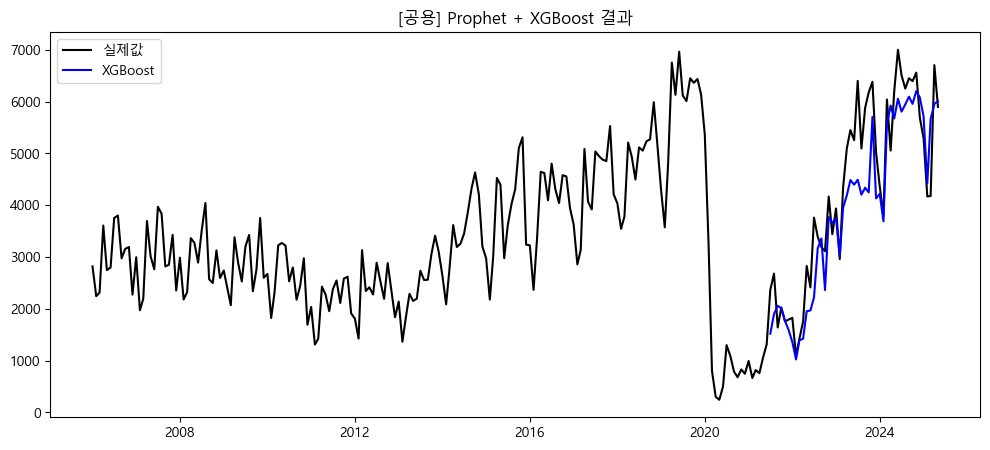

16:30:09 - cmdstanpy - INFO - Chain [1] start processing
16:30:10 - cmdstanpy - INFO - Chain [1] done processing
16:30:10 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 3221225653 
Optimization terminated abnormally. Falling back to Newton.
16:30:10 - cmdstanpy - INFO - Chain [1] start processing
16:30:10 - cmdstanpy - INFO - Chain [1] done processing
16:30:10 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 3221225653 


❌ Prophet 실패(관광): Error during optimization! Command 'C:\Users\Admin\anaconda3\envs\han\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=55232 data file=C:\Users\Admin\AppData\Local\Temp\tmppw0tzrha\xuvbxyox.json init=C:\Users\Admin\AppData\Local\Temp\tmppw0tzrha\h31atix8.json output file=C:\Users\Admin\AppData\Local\Temp\tmppw0tzrha\prophet_modela32neaka\prophet_model-20250714163010.csv method=optimize algorithm=newton iter=10000' failed: 
[관광] Prophet 예측 결과 없음(실패/건너뜀)
[관광] XGBoost 예측 정확도 (테스트셋)
 - RMSE: 170065.1 / MAPE: 31.67% / R²: 0.878 → 👍 예측력 양호


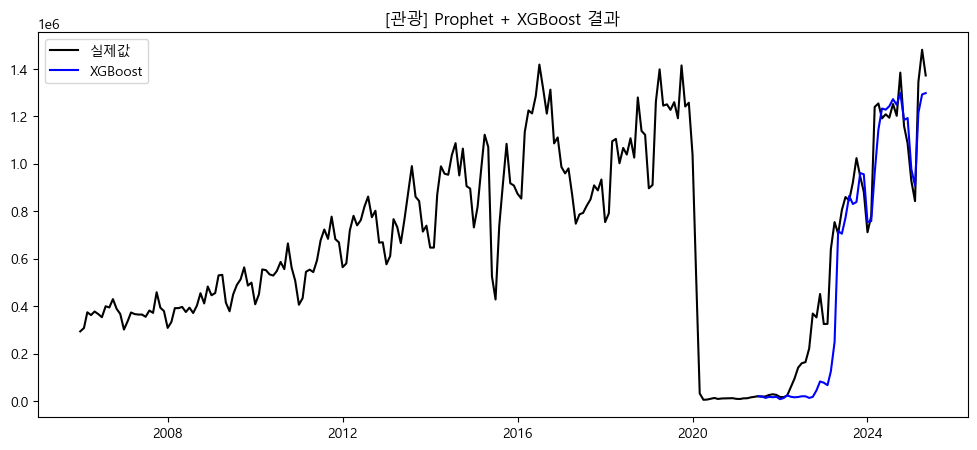

16:30:11 - cmdstanpy - INFO - Chain [1] start processing
16:30:11 - cmdstanpy - INFO - Chain [1] done processing
16:30:11 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 3221225653 
Optimization terminated abnormally. Falling back to Newton.
16:30:11 - cmdstanpy - INFO - Chain [1] start processing
16:30:12 - cmdstanpy - INFO - Chain [1] done processing
16:30:12 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 3221225653 


❌ Prophet 실패(상용): Error during optimization! Command 'C:\Users\Admin\anaconda3\envs\han\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=70105 data file=C:\Users\Admin\AppData\Local\Temp\tmppw0tzrha\ybkq6b77.json init=C:\Users\Admin\AppData\Local\Temp\tmppw0tzrha\di2zbjpj.json output file=C:\Users\Admin\AppData\Local\Temp\tmppw0tzrha\prophet_modelwrdspws4\prophet_model-20250714163011.csv method=optimize algorithm=newton iter=10000' failed: 
[상용] Prophet 예측 결과 없음(실패/건너뜀)
[상용] XGBoost 예측 정확도 (테스트셋)
 - RMSE: 6623.5 / MAPE: 62.89% / R²: -2.127 → ❗ 예측력 낮음 (참고용)


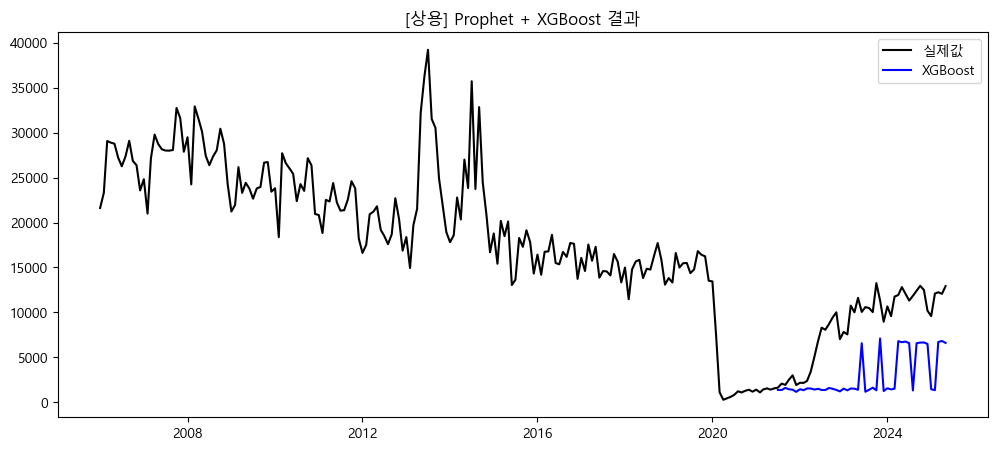

16:30:12 - cmdstanpy - INFO - Chain [1] start processing
16:30:12 - cmdstanpy - INFO - Chain [1] done processing
16:30:12 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 3221225653 
Optimization terminated abnormally. Falling back to Newton.
16:30:13 - cmdstanpy - INFO - Chain [1] start processing
16:30:13 - cmdstanpy - INFO - Chain [1] done processing
16:30:13 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 3221225653 


❌ Prophet 실패(유학연수): Error during optimization! Command 'C:\Users\Admin\anaconda3\envs\han\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=2168 data file=C:\Users\Admin\AppData\Local\Temp\tmppw0tzrha\i21wzheh.json init=C:\Users\Admin\AppData\Local\Temp\tmppw0tzrha\7l9reneu.json output file=C:\Users\Admin\AppData\Local\Temp\tmppw0tzrha\prophet_modelpqirya3e\prophet_model-20250714163013.csv method=optimize algorithm=newton iter=10000' failed: 
[유학연수] Prophet 예측 결과 없음(실패/건너뜀)
[유학연수] XGBoost 예측 정확도 (테스트셋)
 - RMSE: 11164.8 / MAPE: 27.67% / R²: 0.733 → 👍 예측력 양호


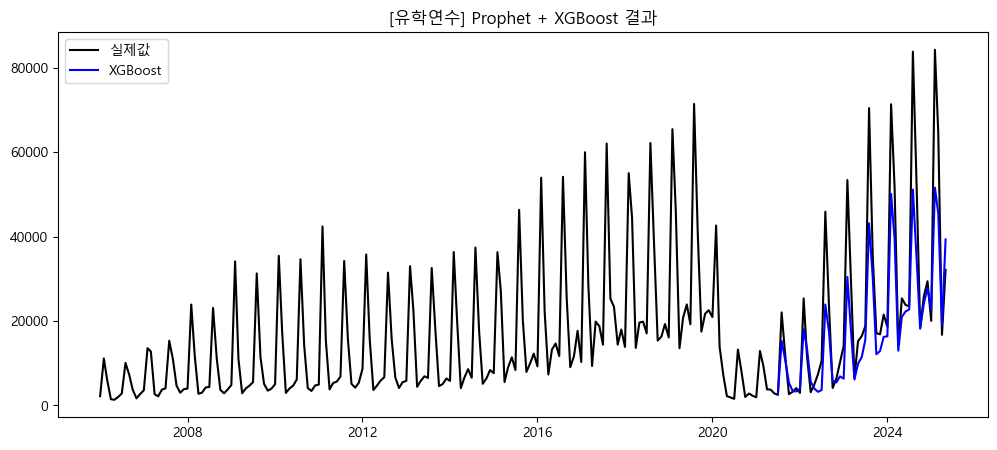


📅 원하는 연월 선택
+---------+---------+---------+---------+---------+---------+
| 2025-07 | 2025-08 | 2025-09 | 2025-10 | 2025-11 | 2025-12 |
+---------+---------+---------+---------+---------+---------+
| 2026-01 | 2026-02 | 2026-03 | 2026-04 | 2026-05 | 2026-06 |
+---------+---------+---------+---------+---------+---------+
| 2026-07 | 2026-08 | 2026-09 | 2026-10 | 2026-11 | 2026-12 |
+---------+---------+---------+---------+---------+---------+
| 2027-01 | 2027-02 | 2027-03 | 2027-04 | 2027-05 | 2027-06 |
+---------+---------+---------+---------+---------+---------+
| 2027-07 |         |         |         |         |         |
+---------+---------+---------+---------+---------+---------+


In [ ]:
import pandas as pd
import numpy as np
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from datetime import datetime
from tabulate import tabulate

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 1. 데이터 로드
df = pd.read_csv('../data/외국인입국자_전처리완료_딥러닝용.csv')  # 파일 경로 수정 필요시 직접 수정

# 2. 파생 변수
df['성수기'] = df['월'].isin([7, 8, 12]).astype(int)
df['명절']  = df['월'].isin([1, 2, 9, 10]).astype(int)
df['코로나'] = (df['연도'] >= 2020).astype(int)
df['연월']  = df['연도'].astype(str) + '-' + df['월'].astype(str).str.zfill(2)
df['lag_1'] = df.groupby(['국적','목적'])['입국자수'].shift(1)
df['lag_3'] = df.groupby(['국적','목적'])['입국자수'].shift(3)
df['lag_12'] = df.groupby(['국적','목적'])['입국자수'].shift(12)
df['rolling_3']  = df.groupby(['국적','목적'])['입국자수'].transform(lambda x: x.rolling(3, min_periods=1).mean())
df['rolling_6']  = df.groupby(['국적','목적'])['입국자수'].transform(lambda x: x.rolling(6, min_periods=1).mean())
df['rolling_12'] = df.groupby(['국적','목적'])['입국자수'].transform(lambda x: x.rolling(12, min_periods=1).mean())
df['yoy'] = df['입국자수'] / df.groupby(['국적','목적'])['입국자수'].shift(12) - 1
df['log_y'] = np.log1p(df['입국자수'].clip(lower=0))
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# 3. 사용자 입력 (유효성 검사)
all_countries = sorted(df['국적'].dropna().unique())
all_purposes = sorted(df['목적'].dropna().unique())

def sanitize(s): return s.strip().replace(' ','').lower()

while True:
    country = input("국적 입력(없으면 Enter): ").strip()
    if not country:
        print("🌍 국적 미선택 → 전체 국가 대상")
        sel_country = None
        break
    matches = [c for c in all_countries if sanitize(country) == sanitize(c)]
    if matches:
        sel_country = matches[0]
        break
    else:
        print(f"❌ '{country}'는 데이터에 없습니다. 다시 입력!")

while True:
    purpose = input("목적 입력(없으면 Enter): ").strip()
    if not purpose:
        print("🗂️ 목적 미선택 → 전체 목적 대상")
        sel_purpose = None
        break
    matches = [p for p in all_purposes if sanitize(purpose) == sanitize(p)]
    if matches:
        sel_purpose = matches[0]
        break
    else:
        print(f"❌ '{purpose}'는 데이터에 없습니다. 다시 입력!")

# 4. 필터
df_filt = df.copy()
if sel_country:
    df_filt = df_filt[df_filt['국적'] == sel_country]
purpose_list = [sel_purpose] if sel_purpose else df_filt['목적'].unique()
if len(df_filt)==0:
    raise Exception("❗ 조건에 맞는 데이터 없음. 종료.")

# groupby: 목적 미선택이면 월+목적별 합계, 목적 선택시 개별 row 유지
if not sel_country:
    grouped = df_filt.groupby(['연월', '목적', '성수기', '명절', '코로나'], as_index=False).agg({
        '입국자수':'sum','lag_1':'sum','lag_3':'sum','lag_12':'sum',
        'rolling_3':'sum','rolling_6':'sum','rolling_12':'sum','yoy':'mean','log_y':'sum'
    })
    grouped['연도'] = grouped['연월'].str[:4].astype(int)
    grouped['월'] = grouped['연월'].str[-2:].astype(int)
else:
    grouped = df_filt.copy()

# 5. 평가 텍스트
def explain_score(r2, mape):
    if r2 >= 0.9:
        return "✅ 예측력 매우 우수 (신뢰도 높음)"
    elif r2 >= 0.7:
        return "👍 예측력 양호"
    elif r2 >= 0.5:
        return "⚠️ 예측력 보통 (개선 가능)"
    else:
        return "❗ 예측력 낮음 (참고용)"

prophet_results, xgb_results, actuals = {}, {}, {}

for pur in purpose_list:
    temp = grouped[grouped['목적']==pur].copy() if '목적' in grouped else grouped.copy()
    if temp.empty:
        print(f"❌ 데이터 없음: {pur}")
        continue
    temp['ds'] = pd.to_datetime(temp['연월'])
    temp['y'] = temp['입국자수']

    # ---- Prophet 안전 실행 ----
    reg_cols = []
    for col in ['성수기','명절','코로나']:
        nun = temp[col].nunique()
        nan = temp[col].isna().sum()
        if nun > 1 and nan==0:
            reg_cols.append(col)
    forecast = None
    if len(temp)>=24 and len(reg_cols)>0:
        m = Prophet(yearly_seasonality=True)
        for c in reg_cols: m.add_regressor(c)
        try:
            m.fit(temp[['ds','y']+reg_cols])
            future = m.make_future_dataframe(periods=24, freq='M')
            future['월'] = future['ds'].dt.month
            future['성수기'] = future['월'].isin([7, 8, 12]).astype(int)
            future['명절'] = future['월'].isin([1, 2, 9, 10]).astype(int)
            future['코로나'] = (future['ds'].dt.year >= 2020).astype(int)
            for c in reg_cols: future[c] = future[c]
            forecast = m.predict(future)
            forecast[['yhat','yhat_lower','yhat_upper']] = forecast[['yhat','yhat_lower','yhat_upper']].clip(lower=0)
            prophet_results[pur] = forecast
        except Exception as e:
            print(f"❌ Prophet 실패({pur}): {str(e)}")
            prophet_results[pur] = None
    else:
        print(f"❗ Prophet 건너뜀({pur}): 데이터 부족/설명변수 상수값/결측")

    # ---- XGB (모든 경우) ----
    temp = temp.dropna()
    features = ['연도','월','lag_1','lag_3','lag_12','rolling_3','rolling_6','rolling_12','yoy','성수기','명절','코로나']
    if not all(f in temp for f in features): continue
    X = temp[features].values
    y = temp['y'].values
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, shuffle=False, test_size=0.2)
    xgb = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1)
    xgb.fit(X_train, y_train)
    y_pred = xgb.predict(X_test)
    xgb_df = pd.DataFrame({'ds': temp.iloc[-len(y_test):]['ds'].values, 'xgb_yhat': np.clip(y_pred,0,None)})
    xgb_results[pur] = xgb_df
    actuals[pur] = temp

    # ---- 성능 평가/출력 ----
    if forecast is not None:
        real = temp['y'][-12:].values
        fcst = forecast['yhat'][:len(real)]
        rmse_p = np.sqrt(mean_squared_error(real, fcst))
        r2_p = r2_score(real, fcst)
        mape_p = mean_absolute_percentage_error(real, fcst) * 100
        print(f"\n[{pur}] Prophet 예측 정확도 (최근 12개월)\n - RMSE: {rmse_p:.1f} / MAPE: {mape_p:.2f}% / R²: {r2_p:.3f} → {explain_score(r2_p, mape_p)}")
    else:
        print(f"[{pur}] Prophet 예측 결과 없음(실패/건너뜀)")

    rmse_x = np.sqrt(mean_squared_error(y_test, y_pred))
    r2_x = r2_score(y_test, y_pred)
    mape_x = mean_absolute_percentage_error(y_test, y_pred) * 100
    print(f"[{pur}] XGBoost 예측 정확도 (테스트셋)\n - RMSE: {rmse_x:.1f} / MAPE: {mape_x:.2f}% / R²: {r2_x:.3f} → {explain_score(r2_x, mape_x)}")

    # ---- 예측 결과 및 그래프 ----
    if forecast is not None:
        last = forecast.iloc[-1]
        print(f"[{pur}] Prophet 미래 마지막달({last['ds'].strftime('%Y-%m')}) 예측값: {int(last['yhat']):,}명 (신뢰구간: {int(last['yhat_lower']):,} ~ {int(last['yhat_upper']):,})")

    plt.figure(figsize=(12,5))
    plt.plot(temp['ds'], temp['y'], label='실제값', color='black')
    if forecast is not None:
        plt.plot(forecast['ds'], forecast['yhat'], label='Prophet', color='red')
        plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                         alpha=0.2, color='pink', label='Prophet 신뢰구간')
    plt.plot(xgb_df['ds'], xgb_df['xgb_yhat'], label='XGBoost', color='blue')
    plt.title(f"[{pur}] Prophet + XGBoost 결과")
    plt.legend()
    plt.show()

# ---- 전체 목적 합계 Prophet (무조건 출력) ----
if len(prophet_results)>0:
    p_concat = [p for p in prophet_results.values() if p is not None]
    if p_concat:
        total_prophet = pd.concat(p_concat).groupby('ds').sum().reset_index()
        total_prophet[['yhat','yhat_lower','yhat_upper']] = total_prophet[['yhat','yhat_lower','yhat_upper']].clip(lower=0)
        total_actuals = pd.concat(actuals.values()).groupby('ds').sum().reset_index()
        real = total_actuals['y'][-12:].values
        fcst = total_prophet['yhat'][:len(real)]
        rmse_p = np.sqrt(mean_squared_error(real, fcst))
        r2_p = r2_score(real, fcst)
        mape_p = mean_absolute_percentage_error(real, fcst) * 100
        print(f"\n[전체 목적] Prophet 예측 정확도 (최근 12개월)\n - RMSE: {rmse_p:.1f} / MAPE: {mape_p:.2f}% / R²: {r2_p:.3f} → {explain_score(r2_p, mape_p)}")
        last = total_prophet.iloc[-1]
        print(f"[전체 목적] Prophet 미래 마지막달({last['ds'].strftime('%Y-%m')}) 예측값: {int(last['yhat']):,}명 (신뢰구간: {int(last['yhat_lower']):,} ~ {int(last['yhat_upper']):,})")
        plt.figure(figsize=(14,6))
        plt.plot(total_actuals['ds'], total_actuals['y'], label='실제값 합계', color='black')
        plt.plot(total_prophet['ds'], total_prophet['yhat'], label='Prophet 합계', color='red')
        plt.fill_between(total_prophet['ds'], total_prophet['yhat_lower'], total_prophet['yhat_upper'],
                         alpha=0.3, color='pink', label='Prophet 신뢰구간')
        plt.title("모든 목적 Prophet 합계")
        plt.legend()
        plt.show()

# ---- 사용자가 월단위 예측 조회 ----
print("\n📅 원하는 연월 선택")
now = pd.to_datetime(datetime.now()).replace(day=1)
possible = pd.date_range(now, now + pd.DateOffset(months=24), freq='MS').strftime('%Y-%m').tolist()
rows = [possible[i:i+6] for i in range(0, len(possible), 6)]
print(tabulate(rows, tablefmt="grid"))
query = input("연월 입력 (YYYYMM or YYYY-MM): ").strip().replace('-', '')
if len(query)==6: query = f"{query[:4]}-{query[4:]}"
query_year = int(query[:4])

if sel_purpose and sel_purpose in prophet_results and prophet_results[sel_purpose] is not None:
    fc = prophet_results[sel_purpose]
    one_year = fc[fc['ds'].dt.year == query_year]
    mask = one_year['ds'].dt.strftime('%Y-%m') == query
    point = one_year[mask]
    if not point.empty:
        row = point.iloc[0]
        y_val, yhat_low, yhat_up = row['yhat'], row['yhat_lower'], row['yhat_upper']
        print(f"\n[{sel_purpose}] {query} 예측: {int(y_val):,}명 (신뢰구간: {int(yhat_low):,} ~ {int(yhat_up):,})")
    else:
        print("❗ 정확한 예측값 없음. 그래프에서 확인 바랍니다.")

elif len(prophet_results)>0:
    p_concat = [p for p in prophet_results.values() if p is not None]
    if p_concat:
        total_prophet = pd.concat(p_concat).groupby('ds').sum().reset_index()
        one_year_sum = total_prophet[total_prophet['ds'].dt.year == query_year]
        mask = one_year_sum['ds'].dt.strftime('%Y-%m') == query
        p2 = one_year_sum[mask]
        if not p2.empty:
            row = p2.iloc[0]
            y_val, yhat_low, yhat_up = row['yhat'], row['yhat_lower'], row['yhat_upper']
            print(f"\n[전체 목적] {query} 예측: {int(y_val):,}명 (신뢰구간: {int(yhat_low):,} ~ {int(yhat_up):,})")
        else:
            print("❗ 정확한 예측값 없음. 그래프에서 확인 바랍니다.")
else:
    print("❗ Prophet 예측 결과 없음(XGB 결과 참고)")

